## Desenvolvimento da base teórica para detectar Marine Heat Waves 

Este é o notebook de desenvolvimento para um método robusto de extração e estatísticas de Marine Heat Wave (MHW) a partir de séries temporais de temperatura da superfície do mar (SST). Existe uma vasta literatura sobre o assunto, incluindo o trabalho clássico de [Hobday et al., 2018](https://doi.org/10.5670/oceanog.2018.205), embora os códigos Python fornecidos naquela época estejam desatualizados em comparação com os avanços mais recentes em python e também em estatísticas.

A ideia aqui é realizar uma adaptação do conceito introduzido por Hobday e colaboradores, onde a principal, e talvez mais significativa diferença, é a possibilidade de comparar um dado monitorado com uma climatologia "externa", ou seja, de outra fonte. A principal motivação para isso é que no caso de bóias meteoceanográficas, há muitos gaps, e a metodologia desenvolvida por Hobday "interpola" esses gaps, o que introduz um viés estatístico com claros impactos na determinação das médias e dos percentis que definem os limites para classificação de eventos extremos de temperatura.<br>
Essa aplicação é especialmente útil quando temos a possibilidade de cruzar dados de satélite (por exemplo, GHRSST ou OISST) que produzem climatolofias estatísticamente mais robustas, com a observação com lacunvas. Um detalhe teórico muito importante é que, se a temperatura média da superfície do mar (SST) aumenta devido ao aquecimento mas a variabilidade (σ) permanece constante, a distribuição da SST se desloca para a direita (valores mais altos). Nesse caso:
- O valor absoluto correspondente ao antigo percentil 90 pode agora estar mais próximo da média, fazendo com que mais dias sejam classificados como MHWs, ou classificar incorretamente a intensidade de uma MHW.
- Se o aquecimento também aumentar a variabilidade (σ), a distribuição se torna mais ampla, o que pode afetar a frequência e a intensidade das MHWs.

### Percentis, z-score e outras figuras estatísticas importantes

Usar percentis para definir MHWs é prático, mas pode levar à saturação da medida com o aquecimento contínuo dos oceanos se o período de referência não for ajustado. Também é importante considerar o desvio padrão da climatologia para capturar mudanças na variabilidade da SST, fornecendo uma visão mais abrangente das MHWs no contexto das mudanças climáticas. Hobday e colegas definiram as categorias de intensidade com base nos percentis abaixo:

| Category | Percentile | Z-Score\* |
|----------|------------|---------|
| 1        | 90%        | 1.28    |
| 2        | 95%        | 1.645   |
| 3        | 98%        | 2.054   |
| 4        | 99%        | 2.33    |

\* note que o z-score é apresentado aqui como uma medida relativa à média da climatologia, *SE e SOMENTE SE* a distribuição for normal.<br>
Os percentis são medidas relativas a toda a observação de dados dividido em 100 partes iguais. O percentil 50, por exemplo, é o valor abaixo do qual 50% dos dados caem (mediana) enquanto que o percentil 90 delimita o valor ultrapassado por apenas 10% apenas das medidas, e assim por diante.

**O primeiro problema do cálculo de Hobday** é justamente esse: ao interpolar gaps, você aumenta o número da sua população e consequentemente os percentis "mudam" também. 

Trabalhar com os percentis é útil por conta da independência do tipo de distribuição, já que percentis são estatísticas não paramétricas, não assumindo nenhuma distribuição específica dos dados, já que é baseado apenas em número. Além disso, percentis são menos influenciados por outliers em comparação com medidas como a média, especialmente em distribuições assimétricas ou com caudas longas. **Note que isso é importante APENAS para a climatologia**.

A principal crítica ao método de Hobday é que ao não considerar uma climatologia completa (ou seja, dados com gaps), a delimitação das temperaturas que marcam a categoria da MHW fica muito prejudicada. Obviamente isso é válido apenas para boias e observações com gaps, o que não é o caso do trabalho de Hobday.

Também é importante notar que Hobday sugere medidas relacionadas a MHW, como $I$ (intensidade), $I_{cum}$, e $I_{max}$, que são calculadas sobre uma climatologia de 30 anos e *uma duração mínima de 5 dias*, permitindo um máximo de 2 dias de queda de $I$ abaixo do percentil 90. O desafio aqui é que os dados de boias frequentemente possuem lacunas, comprometendo as estatísticas de MHW. 

Os testes abaixo foram projetados para abordar essas questões e foram desenvolvidos com base em uma série temporal simples de temperatura da superfície do mar (SST) do Campo de Tupi na Bacia de Santos, extraída do GHRSST (O produto [UKMO-L4HRfnd-GLOB-OSTIA](https://podaac.jpl.nasa.gov/dataset/UKMO-L4HRfnd-GLOB-OSTIA) é coordenado pelo Grupo para Temperatura da Superfície do Mar em Alta Resolução (GHRSST) sob o que chamamos de L4 (Nível 4) e é produzido diariamente de forma operacional pelo UK Met Office, utilizando interpolação ótima (OI) em uma grade global de 0,054 graus (~5 km)). Estes dados estão no arquivo `tupi_OSTIA_sst.parquet`. Também iremos trabalhar com outros dois datasets: `oisst_1982_2011.parquet`, que é a NOAA 1/4° [Daily Optimum Interpolation Sea Surface Temperature (OISST) Version 2.1](https://www.ncei.noaa.gov/products/optimum-interpolation-sst) na posição da boia PIRATA 0°N0°E, e `pirata0n0e.parquet` contendo dados de SST extraidos diretamente do [PMEL NOAA](https://www.pmel.noaa.gov/tao/drupal/disdel/taoftp_access.html).

In [20]:
import pandas as pd

df_tupi = pd.read_parquet('tupi_OSTIA_sst.parquet')

# There is not a great need to strictly follow this pattern, but obviously you
# will need to adapt the code below if you want to change (for example) the column names. 
# Here we are using a time series and will create a "gap" for testing.

# Now I will create a gap in 2013 - that is, a total absence of data.
df_tupi_gap = df_tupi[~df_tupi.index.year.isin([2013])]

In [21]:
# note que esse parquet tem o valore desazonalizado e também o sinal sazonal (mas que não serão usados).
df_tupi_gap.head()

,sst
time,
2008-04-02,26.699999
2008-04-03,26.685713
2008-04-04,26.871426
2008-04-05,26.871426
2008-04-06,26.864283


Note that here, the original data has temporal consistency but with gaps, which hinder the construction of a climatology. Obviously, the two series do not need to be from the same source (in this case, it is GHRSST OSTIA), but the climatology needs to show *statistical consistency*  with the series to be analyzed.


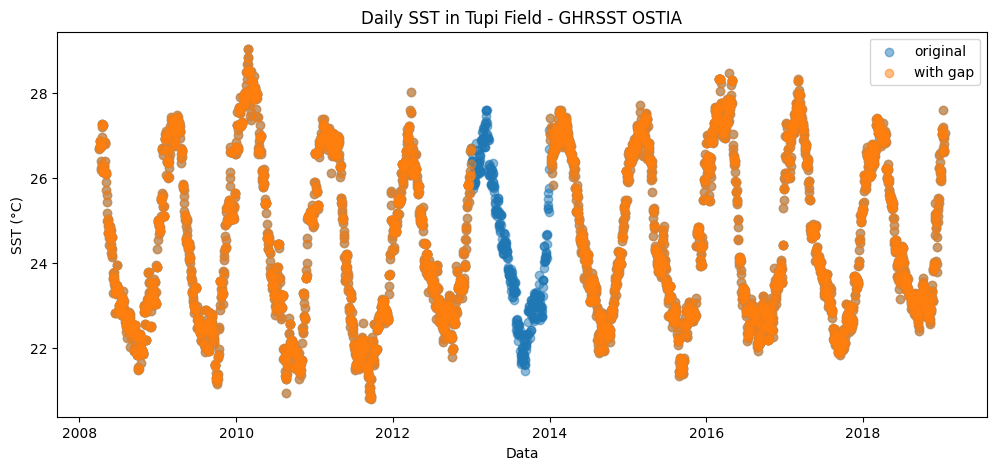

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))
plt.scatter(df_tupi.index,df_tupi.sst,alpha=0.5,label='original')
plt.scatter(df_tupi_gap.index,df_tupi_gap.sst,alpha=0.5,label='with gap')
plt.xlabel('Data')
plt.ylabel('SST (°C)')
plt.title('Daily SST in Tupi Field - GHRSST OSTIA')
plt.legend()
plt.show()

Vamos fazer o mesmo gráfico para a boia PIRATA "0N0E".

In [61]:
df_pirata = pd.read_parquet('pirata0n0e.parquet')
df_oisst = pd.read_parquet('oisst_1982_2011.parquet')

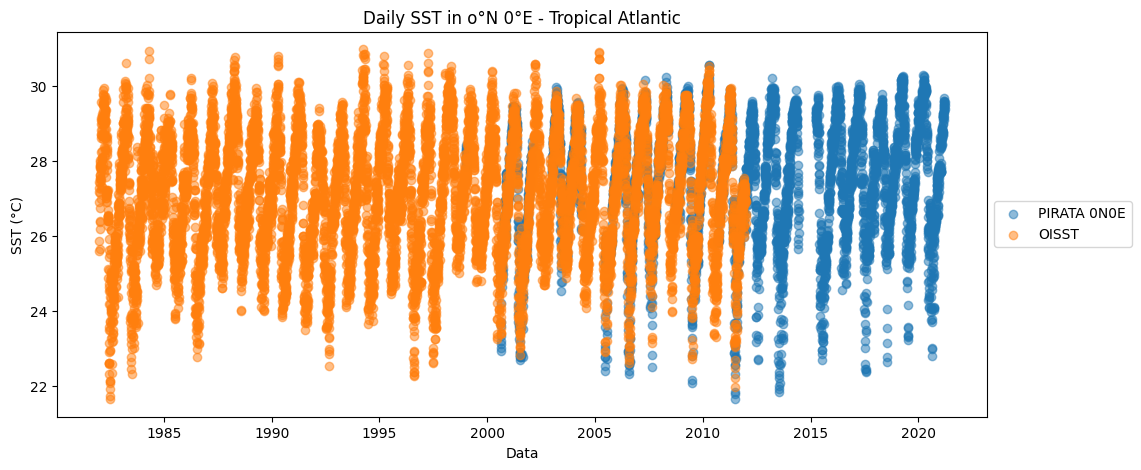

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))
plt.scatter(df_pirata.index,df_pirata.sst,alpha=0.5,label='PIRATA 0N0E')
plt.scatter(df_oisst.index,df_oisst.sst,alpha=0.5,label='OISST')
plt.xlabel('Data')
plt.ylabel('SST (°C)')
plt.title('Daily SST in o°N 0°E - Tropical Atlantic')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Vamos avaliar os limites dos percentis para ambas as séries...

In [76]:
import numpy as np

print('########## Tropical Atlantic ############')

def percentile(dataframe, cut):
    return np.percentile(dataframe.dropna(), cut)

def count_non_nan(dataframe):
    return dataframe.dropna().shape[0]

# Cabeçalhos da tabela
print(f"{'Metric':<25} {'PIRATA':<15} {'OISST':<15}")

# Número de dados disponíveis
print(f"{'Number of Data':<25} {count_non_nan(df_pirata.sst):<15} {count_non_nan(df_oisst.sst):<15}")

# Percentis
print(f"{'Percentile 50 (Median)':<25} {percentile(df_pirata.sst, 50):.2f} {'':<7}| {percentile(df_oisst.sst, 50):.2f}")
print(f"{'Percentile 90':<25} {percentile(df_pirata.sst, 90):.2f} {'':<7}| {percentile(df_oisst.sst, 90):.2f}")
print(f"{'Percentile 95':<25} {percentile(df_pirata.sst, 95):.2f} {'':<7}| {percentile(df_oisst.sst, 95):.2f}")
print(f"{'Percentile 98':<25} {percentile(df_pirata.sst, 98):.2f} {'':<7}| {percentile(df_oisst.sst, 98):.2f}")
print(f"{'Percentile 99':<25} {percentile(df_pirata.sst, 99):.2f} {'':<7}| {percentile(df_oisst.sst, 99):.2f}")



########## Tropical Atlantic ############
Metric                    PIRATA          OISST          
Number of Data            6274            10957          
Percentile 50 (Median)    27.57        | 27.13
Percentile 90             29.43        | 29.18
Percentile 95             29.67        | 29.51
Percentile 98             29.87        | 29.85
Percentile 99             29.98        | 30.07


As diferenças são óbvias por conta do tamanho diferenciado das séries. Mas, vamos examinar a SST no Campo de Tupi, onde um "gap" foi artificialmente introduzido.

In [78]:
import numpy as np

print('########## Tupi Field ############')

def percentile(dataframe, cut):
    return np.percentile(dataframe.dropna(), cut)

def count_non_nan(dataframe):
    return dataframe.dropna().shape[0]

# Cabeçalhos da tabela
print(f"{'Metric':<25} {'Tupi':<15} {'Tupi (Artificial Gap)':<15}")

# Número de dados disponíveis
print(f"{'Number of Data':<25} {count_non_nan(df_tupi.sst):<15} {count_non_nan(df_tupi_gap.sst):<15}")

# Percentis
print(f"{'Percentile 50 (Median)':<25} {percentile(df_tupi.sst, 50):.2f} {'':<7}| {percentile(df_tupi_gap.sst, 50):.2f}")
print(f"{'Percentile 90':<25} {percentile(df_tupi.sst, 90):.2f} {'':<7}| {percentile(df_tupi_gap.sst, 90):.2f}")
print(f"{'Percentile 95':<25} {percentile(df_tupi.sst, 95):.2f} {'':<7}| {percentile(df_tupi_gap.sst, 95):.2f}")
print(f"{'Percentile 98':<25} {percentile(df_tupi.sst, 98):.2f} {'':<7}| {percentile(df_tupi_gap.sst, 98):.2f}")
print(f"{'Percentile 99':<25} {percentile(df_tupi.sst, 99):.2f} {'':<7}| {percentile(df_tupi_gap.sst, 99):.2f}")


########## Tupi Field ############
Metric                    Tupi            Tupi (Artificial Gap)
Number of Data            3942            3577           
Percentile 50 (Median)    24.06        | 24.04
Percentile 90             27.10        | 27.14
Percentile 95             27.40        | 27.44
Percentile 98             27.87        | 27.93
Percentile 99             28.17        | 28.24


Embora os valores dos percentis obtidos para as séries temporais do Tupi Field e do Tupi Field com gap artificial sejam numericamente próximos, as diferenças, embora sutis, são significativas. Os resultados mostram que a introdução de um gap artificial na série temporal pode alterar os percentis calculados, especialmente em valores mais extremos, como os percentis 95, 98 e 99. Isso indica que até mesmo pequenas alterações na disponibilidade de dados podem impactar os limites superiores das distribuições de temperatura.

Essa variação se torna ainda mais crítica quando consideramos a possibilidade de interpolar valores para preencher lacunas na série temporal. A interpolação pode suavizar ou distorcer a variabilidade natural dos dados, resultando em percentis que não refletem fielmente as condições reais. Portanto, a interpolação de valores para o cálculo de percentis não é recomendada, pois pode levar a interpretações incorretas, especialmente em estudos que dependem de limites percentuais precisos para a análise de eventos extremos, como ondas de calor marinhas. Em resumo, para garantir a precisão dos percentis, é preferível trabalhar com os dados originais, sem preenchimento artificial de lacunas.

### Distribuições Normais e Não-Normais

Uma distribuição normal, também conhecida como distribuição gaussiana, é simétrica em torno de sua média, formando uma curva em forma de sino. Nesta distribuição, a maioria dos valores está concentrada em torno da média, com a probabilidade de ocorrências diminuindo à medida que os valores se afastam da média, tanto para valores maiores quanto menores. A distribuição normal é definida pela média e pelo desvio padrão. Por outro lado, distribuições não normais não seguem essa forma simétrica. Elas podem ser assimétricas, com caudas mais longas de um lado (chamadas de distribuição assimétrica positiva ou negativa), ou podem ter mais de um pico (distribuições multimodais).

Em princípio, a distribuição dos dados não afetaria diretamente os percentis, pois os percentis são medidas de posição que não dependem da forma da distribuição. No entanto, é uma prática desejável ao menos verificar a normalidade dos dados para entender melhor suas características. 

Vamos analisar a distribuição das nossas séries...


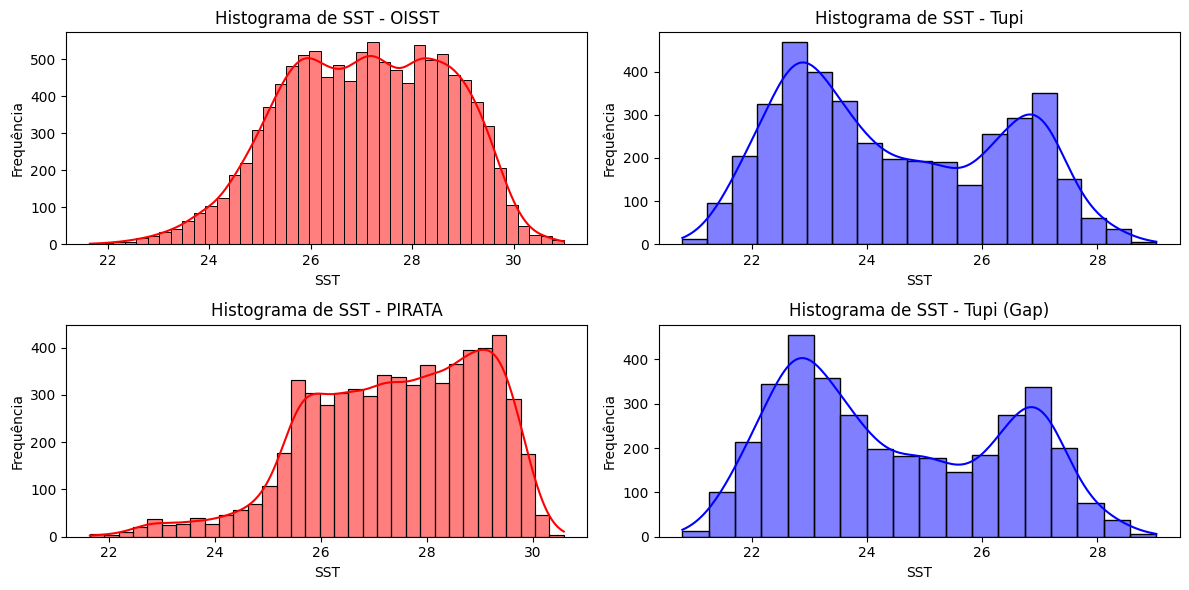

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar a figura e os subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Definir as cores para os gráficos
left_color = 'red'
right_color = 'blue'

# Plotar o histograma de df_oisst (esquerda, acima)
sns.histplot(df_oisst['sst'], kde=True, ax=axes[0, 0], color=left_color)
axes[0, 0].set_title('Histograma de SST - OISST')
axes[0, 0].set_xlabel('SST')
axes[0, 0].set_ylabel('Frequência')

# Plotar o histograma de df_pirata (esquerda, abaixo)
sns.histplot(df_pirata['sst'], kde=True, ax=axes[1, 0], color=left_color)
axes[1, 0].set_title('Histograma de SST - PIRATA')
axes[1, 0].set_xlabel('SST')
axes[1, 0].set_ylabel('Frequência')

# Plotar o histograma de df_tupi (direita, acima)
sns.histplot(df_tupi['sst'], kde=True, ax=axes[0, 1], color=right_color)
axes[0, 1].set_title('Histograma de SST - Tupi')
axes[0, 1].set_xlabel('SST')
axes[0, 1].set_ylabel('Frequência')

# Plotar o histograma de df_tupi_gap (direita, abaixo)
sns.histplot(df_tupi_gap['sst'], kde=True, ax=axes[1, 1], color=right_color)
axes[1, 1].set_title('Histograma de SST - Tupi (Gap)')
axes[1, 1].set_xlabel('SST')
axes[1, 1].set_ylabel('Frequência')

# Ajustar o layout
plt.tight_layout()

# Exibir o gráfico
plt.show()



Enquanto que para a climatologia OISST (esquerda superior) a distribuição é relativamente simétrica com um pico em torno de 27°C a 28°C, e uma curva suavizada que reflete uma distribuição *próxima da normalidade* (mas não normal!) com uma leve cauda à direita, para o dado observado na boia PIRATA (esquerda inferior), a distribuição também é centrada entre 27°C e 28°C, similar ao OISST, mas com uma cauda à esquerda um pouco mais prolongada, indicando a presença de temperaturas ligeiramente mais baixas. Essas distribuições poderiam ser consideradas normais mas não são.

Já para a distribuição de SST em Tupi (direita superior), o histograma mostra uma distribuição bimodal, com dois picos distintos, um em torno de 22°C e outro próximo de 27°C, o que sugere variabilidade significativa nas temperaturas sazonalmente. Para Tupi com Gap artificial (direita inferior), note que a característica bimodal é mantida, mas as frequências mudam ligeiramente, indicando que gaps pode influenciar a distribuição.

Isso só reforça que consistência estatística para a construção da climatologia é essencial.

### Implementando uma análise primária sobre normalidade nos dados

Embora não seja extremamente necessário, 3 testes populares de normalidade podem ser executados.

1. O **Teste de Shapiro-Wilk** é um dos testes mais populares para verificar a normalidade dos dados, particularmente eficaz para amostras pequenas a moderadas.
2. O **Teste de Kolmogorov-Smirnov (K-S)** que compara a distribuição empírica dos seus dados com a distribuição normal teórica, e adequado para grandes amostras.
3. E o **Teste de Anderson-Darling**, uma versão aprimorada do teste K-S e considerado mais poderoso para detectar desvios da normalidade.
4. 
Podemos implementar os 3 com o `scipy`na forma de uma função.

In [100]:
import warnings
from scipy import stats
import pandas as pd

def normality_check(df, column_name):
    # Inicializar um dicionário para armazenar os resultados
    results = {
        "Test": [],
        "Statistic (Expected Range/Value for Normality)": [],
        "Significance Level (%)": [],
        "Critical Values (Thresholds)": [],
        "Conclusion": []
    }

    # Variável para armazenar o aviso
    shapiro_warning = None

    # Teste de Anderson-Darling
    anderson_result = stats.anderson(df[column_name], dist='norm')
    results["Test"].append("Anderson-Darling")
    results["Statistic (Expected Range/Value for Normality)"].append(f"{anderson_result.statistic:.4f} (< {anderson_result.critical_values[2]:.4f})")
    results["Significance Level (%)"].append(", ".join(map(str, anderson_result.significance_level)))
    results["Critical Values (Thresholds)"].append(", ".join(map(lambda x: f"{x:.4f}", anderson_result.critical_values)))

    if anderson_result.statistic < anderson_result.critical_values[2]:  # Nível de 5%
        results["Conclusion"].append("A distribuição parece ser normal (falha em rejeitar H0)")
    else:
        results["Conclusion"].append("A distribuição não é normal (rejeita H0)")

    # Teste de Shapiro-Wilk
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        shapiro_stat, shapiro_p_value = stats.shapiro(df[column_name].dropna())

        # Verificar se o número de dados é superior a 5000
        if len(df[column_name].dropna()) > 5000:
            shapiro_warning = "Aviso: Shapiro-Wilk não é recomendado para N > 5000"

        if shapiro_p_value > 0.05:
            results["Conclusion"].append("A distribuição parece ser normal (falha em rejeitar H0)")
        else:
            results["Conclusion"].append("A distribuição não é normal (rejeita H0)")

    results["Test"].append("Shapiro-Wilk")
    results["Statistic (Expected Range/Value for Normality)"].append(f"{shapiro_stat:.4f} (p > 0.05)")
    results["Significance Level (%)"].append("N/A")
    results["Critical Values (Thresholds)"].append("N/A")

    # Teste de Kolmogorov-Smirnov
    ks_stat, ks_p_value = stats.kstest(df[column_name], 'norm')
    results["Test"].append("Kolmogorov-Smirnov")
    results["Statistic (Expected Range/Value for Normality)"].append(f"{ks_stat:.4f} (p > 0.05)")
    results["Significance Level (%)"].append("N/A")
    results["Critical Values (Thresholds)"].append("N/A")
    if ks_p_value > 0.05:
        results["Conclusion"].append("A distribuição parece ser normal (falha em rejeitar H0)")
    else:
        results["Conclusion"].append("A distribuição não é normal (rejeita H0)")

    # Converter os resultados para um DataFrame
    results_df = pd.DataFrame(results)

    # Exibir o aviso, se aplicável
    if shapiro_warning:
        print("\n" + shapiro_warning)

    return results_df


In [102]:
# verificando para OISST
normality_check(df_oisst.dropna(), 'sst')


Aviso: Shapiro-Wilk não é recomendado para N > 5000


,Test,Statistic (Expected Range/Value for Normality),Significance Level (%),Critical Values (Thresholds),Conclusion
0,Anderson-Darling,41.6848 (< 0.7870),"15.0, 10.0, 5.0, 2.5, 1.0","0.5760, 0.6560, 0.7870, 0.9180, 1.0920",A distribuição não é normal (rejeita H0)
1,Shapiro-Wilk,0.9868 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)
2,Kolmogorov-Smirnov,1.0000 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)


In [103]:
# verificando para SST Pirata
normality_check(df_pirata.dropna(), 'sst')


Aviso: Shapiro-Wilk não é recomendado para N > 5000


,Test,Statistic (Expected Range/Value for Normality),Significance Level (%),Critical Values (Thresholds),Conclusion
0,Anderson-Darling,49.5602 (< 0.7860),"15.0, 10.0, 5.0, 2.5, 1.0","0.5760, 0.6560, 0.7860, 0.9170, 1.0910",A distribuição não é normal (rejeita H0)
1,Shapiro-Wilk,0.9659 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)
2,Kolmogorov-Smirnov,1.0000 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)


In [104]:
# verificando para Tupi OSTIA sst
normality_check(df_tupi.dropna(), 'sst')

,Test,Statistic (Expected Range/Value for Normality),Significance Level (%),Critical Values (Thresholds),Conclusion
0,Anderson-Darling,85.0094 (< 0.7860),"15.0, 10.0, 5.0, 2.5, 1.0","0.5750, 0.6550, 0.7860, 0.9170, 1.0910",A distribuição não é normal (rejeita H0)
1,Shapiro-Wilk,0.9422 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)
2,Kolmogorov-Smirnov,1.0000 (p > 0.05),N/A,N/A,A distribuição não é normal (rejeita H0)


#### Interpretação destes resultados

Todos os resultados aqui indicam uma rejeição de H0 indicando que os dados não seguem uma distribuição normal.
Embora cada teste tenha seus próprios pontos fortes, e a escolha pode depender das características específicas dos seus dados e do tamanho da amostra, é importante aqui ressaltar que conhecer o tamanho, as características estatísticas da série é importante para podermos definir com precisão os valores que irão identificar uma MHW.


**************************************************** parei aqui ********************************

The strategy is to construct a dataframe that contains the climatology of a known period "before" performing the analysis. Unlike Hobday's code, which built the climatology from the series. This climatology here was constructed (for example) between 2008 and 2013 (5 years) from the original series. Note that we do not distinguish leap years (unlike Hobday). Consider that the climatology should have at least 30 years and **can be based on GHRSST**.


In [ ]:
df.index.year # <-- important: your series MUST be time-indexed

Index([2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008,
       ...
       2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019],
      dtype='int32', name='time', length=3876)

In [ ]:
# Climatology between 2008 e 2014 "inclusive" **This is a test**
# The climatology must have statistical consistency, and therefore, when it is constructed,
# it MUST have the same number of samples over the 30 years.

# step 1 - limiting my period and stepdown timeindex
clima = df[(df.index.year >= 2008) & (df.index.year <= 2013)].reset_index()

# step 2 - create mean and std grouping by day of year
df_clima =  clima.groupby(clima.time.dt.dayofyear).agg(['mean','std']).iloc[:,[2,3]]

# Note that the result is a climatology that contains "time" (day of year 1-366) and "std" in the index.
# The latter will be used to calculate the z-score and convert it into a percentile.
df_clima

sst          
           mean       std
time                     
1     25.852856  0.872301
2     25.941428  0.995596
3     26.050000  1.173561
4     25.987143  1.083333
5     25.964286  1.112119
...         ...       ...
362   25.345239  1.149124
363   25.382859  1.202322
364   25.659525  1.023365
365   25.922620  1.019910
366   25.857143  1.191983

[366 rows x 2 columns]

In [ ]:
df_clima.columns # <--- note this is a multi index column


MultiIndex([('sst', 'mean'),
            ('sst',  'std')],
           )

Now the next step is to apply the climatology to the series and extract the MHWs and their respective indices and parameters.


In [ ]:
import pandas as pd
import numpy as np

def detect_MHW(df, df_clima, freq='1D'):
    # Make a copy of the DataFrame to ensure that the original will not be modified.
    df2 = df.copy()
    df2_clima = df_clima.copy()

    # Verify if the index is a DatetimeIndex
    if not isinstance(df2.index, pd.DatetimeIndex):
        try:
            df2.index = pd.to_datetime(df2.index)
        except Exception as e:
            raise ValueError("The index cannot be converted to a DatetimeIndex.") from e

    # Generate an expected regular index based on the provided frequency.
    expected_index = pd.date_range(start=df2.index.min(), end=df2.index.max(), freq=freq)

    # Reindex the DataFrame to ensure it is regular.
    df2 = df2.reindex(expected_index)

    # Some basic statistics:
    # Calculate the time differences between entries in the original index.
    time_diffs = df.index.to_series().diff().dropna()

    # Calculate the mode of the time differences.
    dominant_freq = time_diffs.mode()[0]

    # Compare the dominant frequency with the expected frequency
    expected_freq = pd.Timedelta(freq)
    if dominant_freq != expected_freq:
        raise ValueError(f"The dominant frequency of the data ({dominant_freq}) does not match the expected frequency ({expected_freq}).")

    # Additional statistics
    start_date = df2.index.min()
    end_date = df2.index.max()
    num_points = len(df2)
    num_nans = df2.isna().sum().sum()  # Total number of NaNs
    percent_nans = (num_nans / df2.size) * 100  # Percentage of NaNs

    # Print the statistics
    print(f"Series from {start_date} to {end_date}")
    print(f"Dominant frequency: {dominant_freq}")
    print(f"Number of points: {num_points}")
    print(f"Number of NaNs: {num_nans}")
    print(f"Percentage of NaNs: {percent_nans:.2f}%")

    # Remove the time index and insert dayofyear
    df2 = df2.reset_index().rename(columns={'index':'time'})
    df2['dayofyear'] = df2.time.dt.dayofyear

    # Calculate the anomaly and compare with std
    df2['anomaly'] = df2.apply(lambda row: row['sst'] - df_clima.loc[row['dayofyear'], ('sst', 'mean')], axis=1)
    df2['zscore'] = df2.apply(lambda row: row['anomaly'] / df_clima.loc[row['dayofyear'], ('sst', 'std')], axis=1)

    # Identify periods where the zscore is greater than 1.28 (90%)
    df2['above_90'] = df2['zscore'] > 1.28

    return df2

In [ ]:
def calculate_mhw_periods(df2):
    # Define intensity categories based on z-score thresholds
    categories = [
        (1, 1.28),
        (2, 1.645),
        (3, 2.054),
        (4, 2.33)
    ]

    mhw_periods_list = []

    for category, threshold in categories:
        df2['above_threshold'] = df2['zscore'] > threshold

        # Identify the durations of periods where the zscore is greater than the threshold
        df2['mhw_id'] = (df2['above_threshold'] != df2['above_threshold'].shift()).cumsum()
        mhw_periods = df2[df2['above_threshold']].groupby('mhw_id').agg(
            start=('time', 'min'),
            end=('time', 'max'),
            duration=('time', 'count'),
            max_zscore=('zscore', 'max'),
            cum_zscore=('zscore', 'sum')
        ).reset_index(drop=True)

        # Filter out periods with duration less than or equal to 5 days
        mhw_periods = mhw_periods[mhw_periods['duration'] > 5]

        # Assign the category to the mhw_periods
        mhw_periods['category'] = category

        mhw_periods_list.append(mhw_periods)

    # Concatenate all mhw_periods into a single dataframe
    mhw_periods_all = pd.concat(mhw_periods_list, ignore_index=True)

    # Rename max_zscore to I_max and cum_zscore to I_cum for each MHW period
    mhw_periods_all = mhw_periods_all.rename(columns={'max_zscore': 'I_max', 'cum_zscore': 'I_cum'})

    return mhw_periods_all

Let's execute this code ...

In [ ]:
df_temp = detect_MHW(df,df_clima)

Series from 2008-04-02 00:00:00 to 2019-01-16 00:00:00
Dominant frequency: 1 days 00:00:00
Number of points: 3942
Number of NaNs: 66
Percentage of NaNs: 1.67%


In [ ]:
mhw = calculate_mhw_periods(df_temp)
mhw

,start,end,duration,I_max,I_cum,category
0,2009-11-03,2009-11-29,27,1.942818,46.549727,1
1,2009-12-03,2009-12-09,7,1.695642,11.143071,1
2,2010-01-10,2010-01-20,11,1.672260,17.454598,1
3,2010-02-09,2010-03-08,28,1.729541,44.320430,1
4,2010-03-11,2010-03-23,13,1.733900,21.304027,1
5,2010-03-28,2010-04-02,6,1.501984,8.352464,1
6,2010-04-04,2010-04-11,8,1.670665,12.278246,1
7,2010-05-07,2010-05-19,13,1.932171,21.632980,1
8,2010-07-14,2010-07-19,6,1.746794,9.221314,1
9,2013-06-12,2013-06-18,7,1.660244,10.607288,1


Now testing some graphics

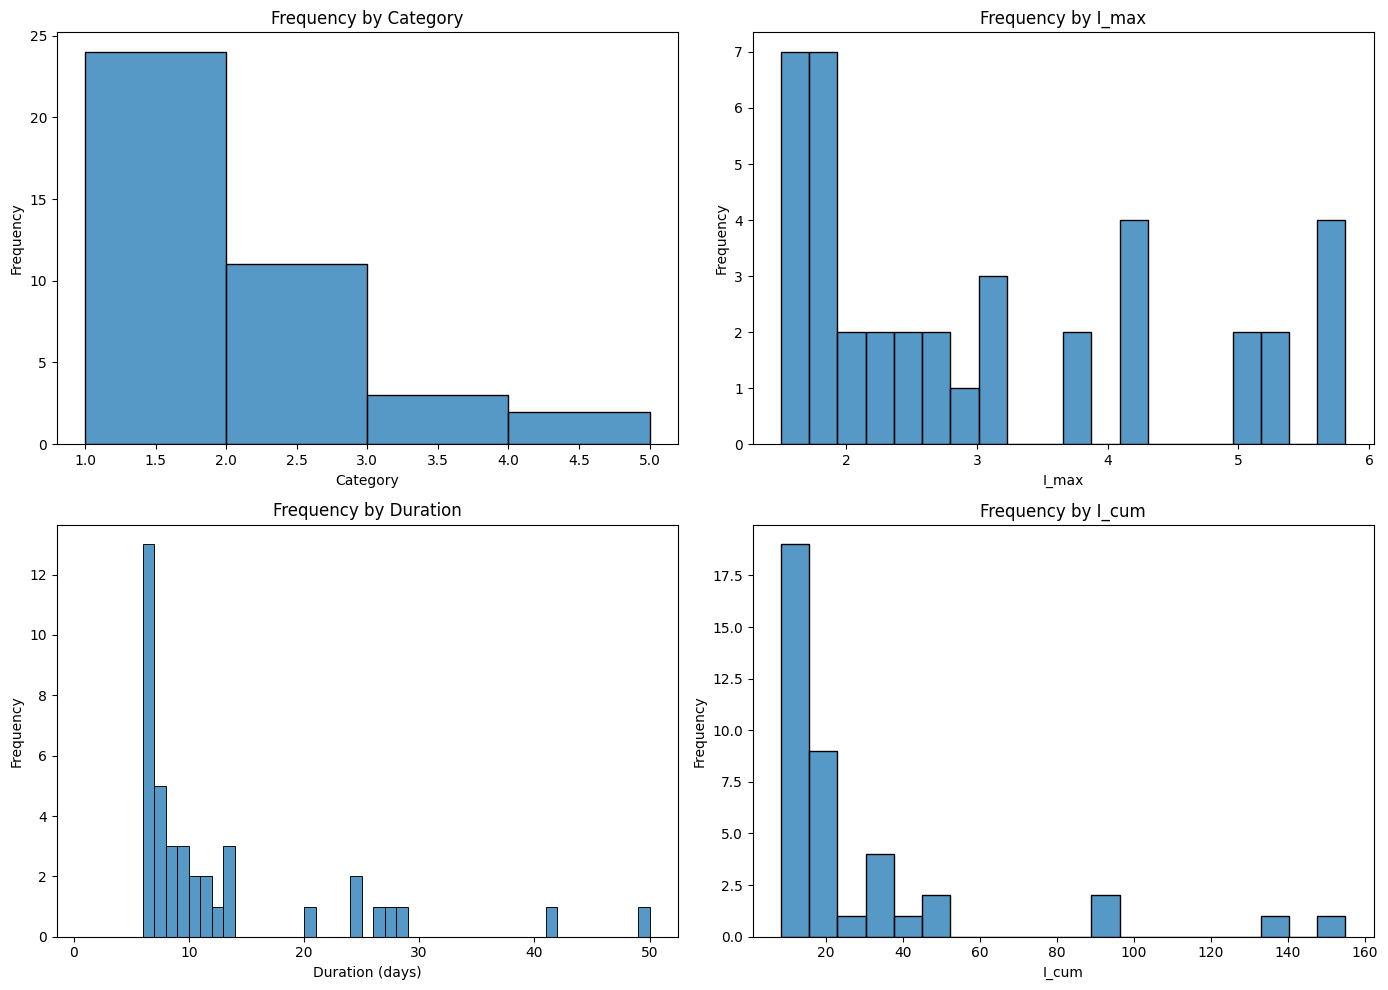

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Previous functions here...

# Assuming df and df_clima are your already loaded DataFrames
# df_temp = detect_MHW(df, df_clima)
# mhw = calculate_mhw_periods(df_temp)

# Create combined histograms
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of frequency by category
sns.histplot(mhw['category'], bins=range(1, mhw['category'].max() + 2), kde=False, ax=ax[0, 0])
ax[0, 0].set_title('Frequency by Category')
ax[0, 0].set_xlabel('Category')
ax[0, 0].set_ylabel('Frequency')

# Histogram of frequency by I_max
sns.histplot(mhw['I_max'], bins=20, kde=False, ax=ax[0, 1])
ax[0, 1].set_title('Frequency by I_max')
ax[0, 1].set_xlabel('I_max')
ax[0, 1].set_ylabel('Frequency')

# Histogram of frequency by duration
sns.histplot(mhw['duration'], bins=range(1, mhw['duration'].max() + 2), kde=False, ax=ax[1, 0])
ax[1, 0].set_title('Frequency by Duration')
ax[1, 0].set_xlabel('Duration (days)')
ax[1, 0].set_ylabel('Frequency')

# Histogram of frequency by I_cum
sns.histplot(mhw['I_cum'], bins=20, kde=False, ax=ax[1, 1])
ax[1, 1].set_title('Frequency by I_cum')
ax[1, 1].set_xlabel('I_cum')
ax[1, 1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()



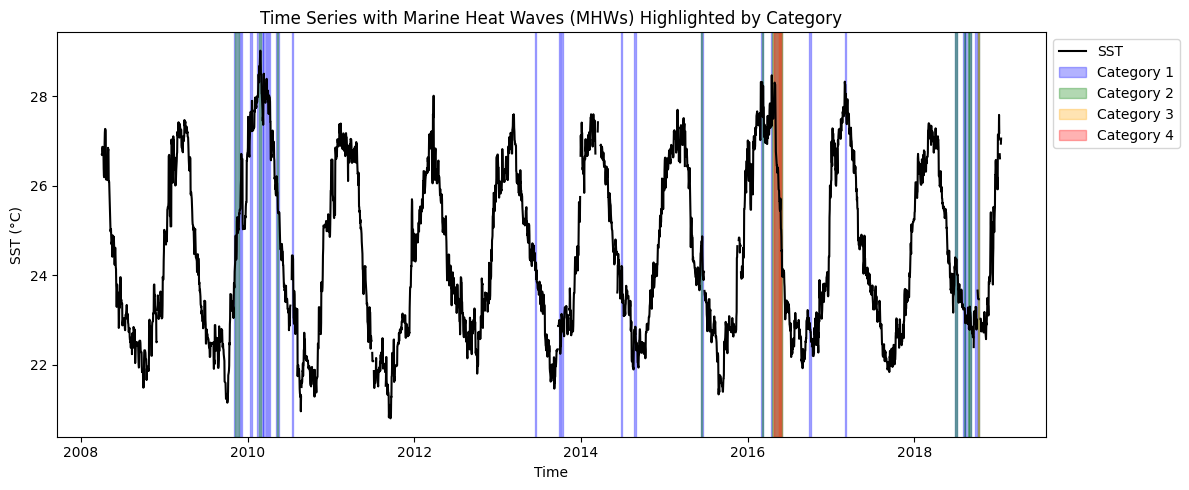

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming previous functions are defined and mhw is calculated
# df_temp = detect_MHW(df, df_clima)
# mhw = calculate_mhw_periods(df_temp)

# Create a color map for the categories
category_colors = {
    1: 'blue',
    2: 'green',
    3: 'orange',
    4: 'red'
}

# Plot the time series and mark MHWs
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the SST time series
ax.plot(df_temp['time'], df_temp['sst'], label='SST', color='black')

# Highlight MHWs with different colors based on category
for _, row in mhw.iterrows():
    start = row['start']
    end = row['end']
    category = row['category']
    ax.axvspan(start, end, color=category_colors[category], alpha=0.3, label=f'Category {category}')

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('SST (°C)')
ax.set_title('Time Series with Marine Heat Waves (MHWs) Highlighted by Category')

# Create a custom legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# Place the legend outside the plot
ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1))

# Show plot
plt.tight_layout()
plt.show()


## Conclusion

This analysis provides a comprehensive overview of Marine Heat Waves (MHWs) within the observed sea surface temperature (SST) time series. By utilizing z-scores and percentile-based thresholds, we were able to categorize MHWs into four distinct categories, each reflecting different levels of intensity based on the maximum z-score ($I_{max}$) and cumulative z-score ($I_{cum}$).

![](https://i.pinimg.com/originals/c3/68/d1/c368d1963574e75c9226faf041054e69.gif)
